# Research07: Filtered Masking Diffusion의 비정확도 강점 검증

Research05/06 결과에서는 전통 증강 `Magnitude warping`이 F1과 AUPRC에서 가장 높았지만, `Filtered@750 Masking Diffusion`은 recall에서 근소하게 더 높은 결과를 보였다. 따라서 Research07은 생성 모델을 단순 최고 정확도 경쟁으로만 평가하지 않고, 다음 세 가지 관점에서 강점을 검증한다.

1. 성능 안정성: 반복 seed에 따른 F1/Recall/AUPRC 변동 폭이 작은가?
2. Recall-oriented robustness: precision constraint 아래에서 높은 recall을 유지하는 threshold 구간이 넓은가?
3. 소수 anomaly seed 효율성: real anomaly seed가 줄어도 성능을 더 잘 유지하는가?

비교의 중심 생성 모델은 `Filtered@750 Masking Diffusion`으로 둔다. 보조 비교로 plain `Masking Diffusion`, 전통 증강 대표 `Magnitude warping`, 그리고 `Original only`를 함께 사용한다.

해석 주의: 현재 저장된 `diffusion_masked_windows.npz`는 Research02에서 한 번 생성된 generated pool이다. 따라서 이 노트북의 stability 실험은 seed별로 생성 모델을 완전히 재학습/재생성하는 엄밀한 실험이 아니라, 같은 generated pool에서 filtering, sampling, classifier training을 반복하는 1차 안정성 검증이다. 엄밀한 생성 seed 안정성은 Research02 generation 자체를 seed별로 반복 실행해야 한다.

In [12]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

ROOT = Path('..').resolve()
sys.path.append(str(ROOT / 'tools'))

from research05_balanced_aug_experiment import (
    NORMAL_TRAIN_SIZE,
    THRESHOLDS,
    FBETA_BETA,
    flatten_windows,
    load_npz_x,
    load_npz_xy,
    sample_rows,
    magnitude_warp,
    quality_filter_generated_anomalies,
    select_threshold_by_validation_f1,
)

SPLIT_DIR = ROOT / 'data' / 'augmentation_split'
GENERATED_DIR = ROOT / 'data' / 'research02' / 'generated'
RESULT_DIR = ROOT / 'data' / 'research07' / 'results'
FIGURE_DIR = ROOT / 'data' / 'research07' / 'figures'
RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

x_normal_train, _ = load_npz_xy(SPLIT_DIR / 'normal_train_windows.npz')
x_anomaly_seed_all, _ = load_npz_xy(SPLIT_DIR / 'anomaly_train_seed_windows.npz')
x_val, y_val = load_npz_xy(SPLIT_DIR / 'validation_windows.npz')
x_final, y_final = load_npz_xy(SPLIT_DIR / 'final_test_windows.npz')
x_masking_diffusion_pool = load_npz_x(GENERATED_DIR / 'diffusion_masked_windows.npz')

print('normal_train:', x_normal_train.shape)
print('anomaly_seed:', x_anomaly_seed_all.shape)
print('validation:', x_val.shape, y_val.shape)
print('final_test:', x_final.shape, y_final.shape)
print('masking_diffusion_pool:', x_masking_diffusion_pool.shape)

normal_train: (135730, 30, 5)
anomaly_seed: (247, 30, 5)
validation: (1447, 30, 5) (1447,)
final_test: (3081, 30, 5) (3081,)
masking_diffusion_pool: (1000, 30, 5)


## 공통 평가 함수

Research05와 같은 방향으로 `imbalanced` 조건을 기본 비교 조건으로 둔다. 정상 데이터는 최대 5,000개를 사용하고, anomaly 학습 데이터는 real anomaly seed와 augmentation 데이터를 합쳐 구성한다. Threshold는 validation F1 기준으로 선택한다.

In [13]:
def evaluate_augmented_rf(
    method,
    augmentation_family,
    x_anomaly_seed,
    x_generated=None,
    generated_count=1000,
    seed=42,
    normal_train_size=NORMAL_TRAIN_SIZE,
):
    if x_generated is None:
        generated_sample = None
        x_anomaly_train = x_anomaly_seed
        generated_used = 0
    else:
        generated_sample = sample_rows(x_generated, generated_count, seed=seed + 11)
        x_anomaly_train = np.concatenate([x_anomaly_seed, generated_sample], axis=0)
        generated_used = len(generated_sample)

    normal_used = min(normal_train_size, len(x_normal_train))
    x_normal_sample = sample_rows(x_normal_train, normal_used, seed=seed + 23)
    x_train = np.concatenate([x_normal_sample, x_anomaly_train], axis=0)
    y_train = np.concatenate([
        np.zeros(len(x_normal_sample), dtype=np.int8),
        np.ones(len(x_anomaly_train), dtype=np.int8),
    ])

    model = RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight='balanced_subsample',
        random_state=seed,
        n_jobs=-1,
    )
    model.fit(flatten_windows(x_train), y_train)

    val_proba = model.predict_proba(flatten_windows(x_val))[:, 1]
    final_proba = model.predict_proba(flatten_windows(x_final))[:, 1]
    threshold_result = select_threshold_by_validation_f1(y_val, val_proba)
    threshold = threshold_result['threshold']
    final_pred = (final_proba >= threshold).astype(np.int8)

    return {
        'method': method,
        'augmentation_family': augmentation_family,
        'seed': seed,
        'normal_train_used': int(len(x_normal_sample)),
        'real_anomaly_seed_used': int(len(x_anomaly_seed)),
        'generated_anomaly_used': int(generated_used),
        'total_anomaly_train_used': int(len(x_anomaly_train)),
        'normal_to_anomaly_ratio': float(len(x_normal_sample) / len(x_anomaly_train)),
        'threshold': float(threshold),
        'validation_precision': float(threshold_result['validation_precision']),
        'validation_recall': float(threshold_result['validation_recall']),
        'validation_f1': float(threshold_result['validation_f1']),
        'precision': precision_score(y_final, final_pred, zero_division=0),
        'recall': recall_score(y_final, final_pred, zero_division=0),
        'f1': f1_score(y_final, final_pred, zero_division=0),
        'f2': fbeta_score(y_final, final_pred, beta=FBETA_BETA, zero_division=0),
        'auroc': roc_auc_score(y_final, final_proba),
        'auprc': average_precision_score(y_final, final_proba),
        'pred_anomaly': int((final_pred == 1).sum()),
        'false_negative': int(((y_final == 1) & (final_pred == 0)).sum()),
        'false_positive': int(((y_final == 0) & (final_pred == 1)).sum()),
    }


def threshold_sweep_for_method(method, augmentation_family, x_anomaly_seed, x_generated=None, generated_count=1000, seed=42):
    if x_generated is None:
        x_anomaly_train = x_anomaly_seed
        generated_used = 0
    else:
        generated_sample = sample_rows(x_generated, generated_count, seed=seed + 11)
        x_anomaly_train = np.concatenate([x_anomaly_seed, generated_sample], axis=0)
        generated_used = len(generated_sample)

    x_normal_sample = sample_rows(x_normal_train, NORMAL_TRAIN_SIZE, seed=seed + 23)
    x_train = np.concatenate([x_normal_sample, x_anomaly_train], axis=0)
    y_train = np.concatenate([
        np.zeros(len(x_normal_sample), dtype=np.int8),
        np.ones(len(x_anomaly_train), dtype=np.int8),
    ])

    model = RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight='balanced_subsample',
        random_state=seed,
        n_jobs=-1,
    )
    model.fit(flatten_windows(x_train), y_train)

    val_proba = model.predict_proba(flatten_windows(x_val))[:, 1]
    final_proba = model.predict_proba(flatten_windows(x_final))[:, 1]
    rows = []
    for threshold in THRESHOLDS:
        val_pred = (val_proba >= threshold).astype(np.int8)
        final_pred = (final_proba >= threshold).astype(np.int8)
        rows.append({
            'method': method,
            'augmentation_family': augmentation_family,
            'seed': seed,
            'generated_anomaly_used': generated_used,
            'threshold': float(threshold),
            'validation_precision': precision_score(y_val, val_pred, zero_division=0),
            'validation_recall': recall_score(y_val, val_pred, zero_division=0),
            'validation_f1': f1_score(y_val, val_pred, zero_division=0),
            'precision': precision_score(y_final, final_pred, zero_division=0),
            'recall': recall_score(y_final, final_pred, zero_division=0),
            'f1': f1_score(y_final, final_pred, zero_division=0),
            'f2': fbeta_score(y_final, final_pred, beta=FBETA_BETA, zero_division=0),
            'auprc': average_precision_score(y_final, final_proba),
            'false_negative': int(((y_final == 1) & (final_pred == 0)).sum()),
            'false_positive': int(((y_final == 0) & (final_pred == 1)).sum()),
        })
    return pd.DataFrame(rows)


def stability_summary(df, metrics=('precision', 'recall', 'f1', 'f2', 'auprc')):
    rows = []
    for method, group in df.groupby('method'):
        row = {'method': method, 'n_runs': len(group)}
        for metric in metrics:
            mean = group[metric].mean()
            std = group[metric].std(ddof=1)
            row[f'{metric}_mean'] = mean
            row[f'{metric}_std'] = std
            row[f'{metric}_min'] = group[metric].min()
            row[f'{metric}_max'] = group[metric].max()
            row[f'{metric}_range'] = group[metric].max() - group[metric].min()
            row[f'{metric}_cv'] = std / mean if mean != 0 else np.nan
        rows.append(row)
    return pd.DataFrame(rows)

## 1. 성능 안정성 실험

목적은 평균 성능만이 아니라 seed 반복 시 성능 변동 폭을 비교하는 것이다. 비교 대상은 다음과 같다.

- `Original only`: augmentation 없음
- `Magnitude warping`: Research05에서 imbalanced 조건 전체 최고 F1/AUPRC를 보인 전통 증강
- `Masking Diffusion`: filtering 없는 생성 모델
- `Filtered@750 Masking Diffusion`: Research06에서 recall 우위를 보인 filtered 생성 모델

엄밀한 생성 안정성을 보려면 Research02 generation 자체를 seed별로 다시 실행해야 한다. 여기서는 1차 검증으로 RandomForest seed, normal sample selection, traditional augmentation generation, generated pool sampling을 반복한다.

,method,augmentation_family,seed,normal_train_used,real_anomaly_seed_used,generated_anomaly_used,total_anomaly_train_used,normal_to_anomaly_ratio,threshold,validation_precision,...,validation_f1,precision,recall,f1,f2,auroc,auprc,pred_anomaly,false_negative,false_positive
3,Filtered@750 Masking Diffusion,generative_filtered,100,5000,247,750,997,5.015045,0.89,1.000000,...,0.776119,1.000000,0.641892,0.781893,0.691412,0.988062,0.923181,190,106,0
7,Filtered@750 Masking Diffusion,generative_filtered,101,5000,247,750,997,5.015045,0.86,0.859375,...,0.753425,0.817164,0.739865,0.776596,0.754132,0.986189,0.886922,268,77,49
11,Filtered@750 Masking Diffusion,generative_filtered,102,5000,247,750,997,5.015045,0.89,0.832000,...,0.719723,0.842795,0.652027,0.735238,0.682944,0.982545,0.877339,229,103,36
15,Filtered@750 Masking Diffusion,generative_filtered,103,5000,247,750,997,5.015045,0.87,0.666667,...,0.680597,0.678679,0.763514,0.718601,0.744891,0.977008,0.846696,333,70,107
19,Filtered@750 Masking Diffusion,generative_filtered,104,5000,247,750,997,5.015045,0.87,0.837209,...,0.737201,0.881356,0.702703,0.781955,0.732394,0.987641,0.910436,236,88,28


,method,n_runs,precision_mean,precision_std,precision_min,precision_max,precision_range,precision_cv,recall_mean,recall_std,...,f2_min,f2_max,f2_range,f2_cv,auprc_mean,auprc_std,auprc_min,auprc_max,auprc_range,auprc_cv
1,Magnitude warping,30,0.930763,0.043089,0.832237,0.990950,0.158713,0.046294,0.801914,0.054276,...,0.701374,0.893342,0.191969,0.053224,0.949958,0.016474,0.909651,0.973273,0.063621,0.017342
2,Masking Diffusion,30,0.929340,0.050814,0.806228,0.995169,0.188941,0.054678,0.739752,0.057068,...,0.645395,0.847811,0.202416,0.060870,0.924280,0.020974,0.878299,0.960288,0.081989,0.022693
3,Original only,30,0.837606,0.086284,0.660377,0.971831,0.311454,0.103012,0.564414,0.063897,...,0.499630,0.679181,0.179551,0.086177,0.784387,0.021990,0.708202,0.815263,0.107061,0.028035
0,Filtered@750 Masking Diffusion,30,0.898900,0.072681,0.678679,1.000000,0.321321,0.080855,0.715878,0.073356,...,0.596633,0.829890,0.233257,0.081886,0.910983,0.026718,0.846696,0.955137,0.108441,0.029328


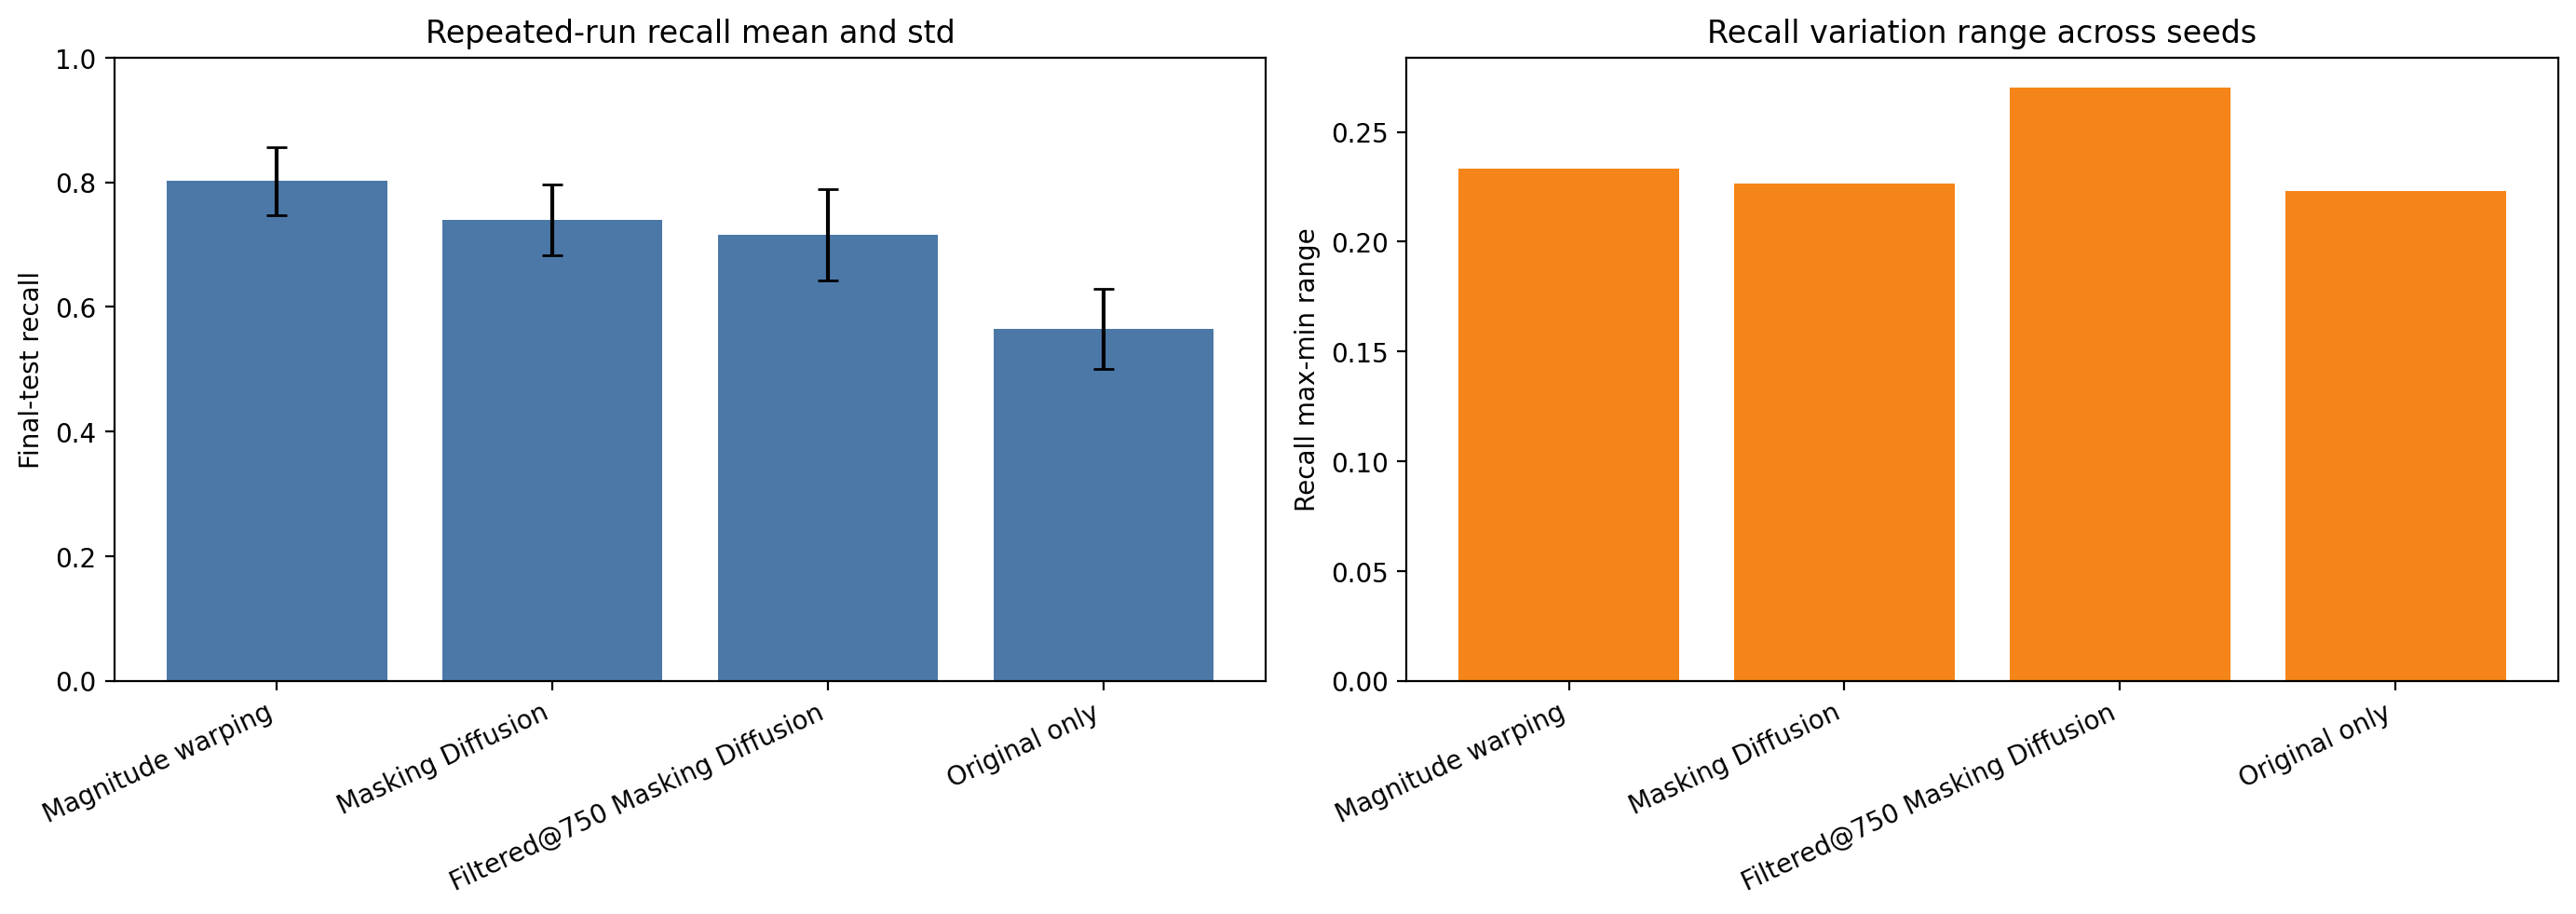

In [14]:
STABILITY_SEEDS = list(range(100, 130))
stability_rows = []

for seed in STABILITY_SEEDS:
    filtered_md = quality_filter_generated_anomalies(
        x_generated=x_masking_diffusion_pool,
        x_anomaly_seed=x_anomaly_seed_all,
        x_normal_train=sample_rows(x_normal_train, NORMAL_TRAIN_SIZE, seed=seed + 31),
        n_select=750,
    )
    magnitude_generated = magnitude_warp(x_anomaly_seed_all, n_generate=1000, seed=seed + 102)

    stability_rows.append(evaluate_augmented_rf(
        method='Original only',
        augmentation_family='none',
        x_anomaly_seed=x_anomaly_seed_all,
        x_generated=None,
        generated_count=0,
        seed=seed,
    ))
    stability_rows.append(evaluate_augmented_rf(
        method='Magnitude warping',
        augmentation_family='traditional',
        x_anomaly_seed=x_anomaly_seed_all,
        x_generated=magnitude_generated,
        generated_count=1000,
        seed=seed,
    ))
    stability_rows.append(evaluate_augmented_rf(
        method='Masking Diffusion',
        augmentation_family='generative',
        x_anomaly_seed=x_anomaly_seed_all,
        x_generated=x_masking_diffusion_pool,
        generated_count=1000,
        seed=seed,
    ))
    stability_rows.append(evaluate_augmented_rf(
        method='Filtered@750 Masking Diffusion',
        augmentation_family='generative_filtered',
        x_anomaly_seed=x_anomaly_seed_all,
        x_generated=filtered_md,
        generated_count=750,
        seed=seed,
    ))

stability_df = pd.DataFrame(stability_rows)
stability_df.to_csv(RESULT_DIR / 'research07_stability_runs.csv', index=False)

stability_stats = stability_summary(stability_df)
stability_stats.to_csv(RESULT_DIR / 'research07_stability_summary.csv', index=False)

display(stability_df.sort_values(['method', 'seed']).head())
display(stability_stats.sort_values('recall_std'))

plot_df = stability_stats.sort_values('recall_mean', ascending=False).copy()
x = np.arange(len(plot_df))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(x, plot_df['recall_mean'], yerr=plot_df['recall_std'], capsize=4, color='#4C78A8')
axes[0].set_xticks(x)
axes[0].set_xticklabels(plot_df['method'], rotation=25, ha='right')
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel('Final-test recall')
axes[0].set_title('Repeated-run recall mean and std')

axes[1].bar(x, plot_df['recall_range'], color='#F58518')
axes[1].set_xticks(x)
axes[1].set_xticklabels(plot_df['method'], rotation=25, ha='right')
axes[1].set_ylabel('Recall max-min range')
axes[1].set_title('Recall variation range across seeds')

stability_figure_path = FIGURE_DIR / 'research07_stability_recall_comparison.png'
fig.tight_layout()
fig.savefig(stability_figure_path, dpi=200, bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(stability_figure_path)))

해석 기준:

- `recall_std`, `recall_range`, `recall_cv`가 작으면 recall 안정성이 높다.
- 평균 F1/AUPRC가 조금 낮더라도 recall 변동 폭이 작으면, 생성모델은 안정성 중심 증강으로 주장할 수 있다.
- 반대로 filtered 생성모델의 변동 폭이 전통 증강보다 크면, 안정성 주장은 제외하고 threshold robustness 또는 seed efficiency 중심으로 해석한다.

그래프 해석:

- 왼쪽 그래프는 반복 실행에서의 평균 recall과 표준편차를 보여준다. 막대가 높고 error bar가 짧을수록 안정적인 recall 성능으로 해석한다.
- 오른쪽 그래프는 seed 반복에서 발생한 recall의 최대-최소 범위를 보여준다. 값이 작을수록 반복 생성/학습 조건 변화에 덜 민감하다고 볼 수 있다.

## 2. Recall-oriented robustness 실험

threshold를 0.05부터 0.95까지 sweep하면서, validation precision floor를 만족하는 threshold 중 recall이 얼마나 높고 안정적으로 유지되는지 확인한다.

주요 지표:

- `max_final_recall_at_floor`: validation precision floor를 만족하는 threshold 중 final recall 최대값
- `n_thresholds_at_floor`: precision floor를 만족하는 threshold 개수
- `n_high_recall_thresholds_at_floor`: precision floor를 만족하면서 final recall도 기준 이상인 threshold 개수
- `threshold_width_at_floor`: 조건을 만족하는 threshold 구간 폭

여기서는 `precision >= 0.90`, `recall >= 0.80`을 기본 기준으로 둔다.

,method,precision_floor,n_thresholds_at_floor,max_final_recall_at_floor,best_final_precision_at_floor,best_threshold_at_floor,n_high_recall_thresholds_at_floor,threshold_width_at_floor,mean_recall_at_floor,std_recall_at_floor
1,Magnitude warping,0.9,16,0.858108,0.910394,0.80,3,0.02,0.586360,0.195374
0,Filtered@750 Masking Diffusion,0.9,12,0.831081,0.904412,0.84,2,0.01,0.597691,0.156983
2,Masking Diffusion,0.9,12,0.824324,0.913858,0.84,2,0.01,0.612613,0.163083
3,Original only,0.9,5,0.564189,0.922652,0.91,0,0.00,0.434459,0.112723


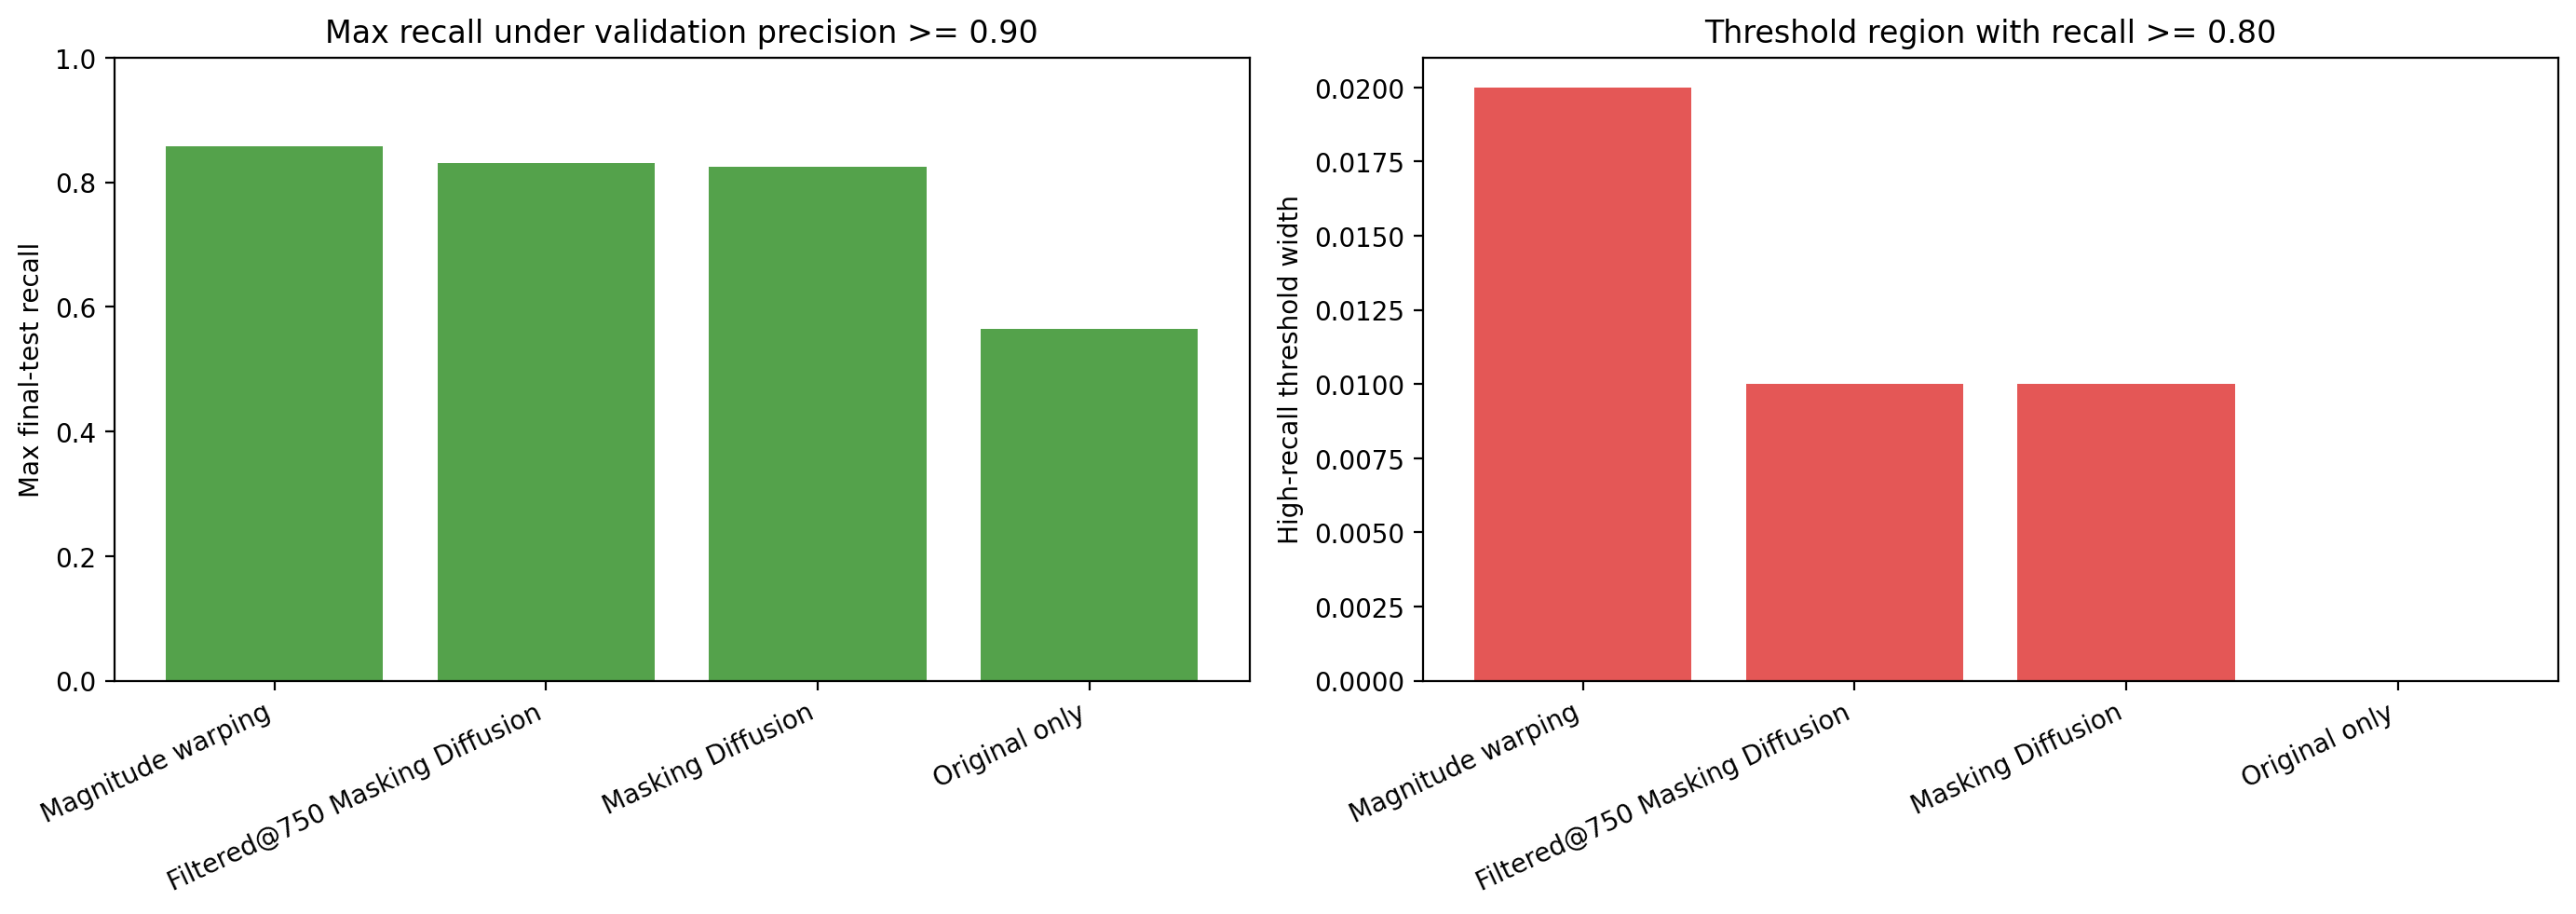

In [15]:
ROBUSTNESS_SEED = 42
PRECISION_FLOOR = 0.90
HIGH_RECALL_FLOOR = 0.80

filtered_md = quality_filter_generated_anomalies(
    x_generated=x_masking_diffusion_pool,
    x_anomaly_seed=x_anomaly_seed_all,
    x_normal_train=sample_rows(x_normal_train, NORMAL_TRAIN_SIZE, seed=ROBUSTNESS_SEED + 31),
    n_select=750,
)
magnitude_generated = magnitude_warp(x_anomaly_seed_all, n_generate=1000, seed=ROBUSTNESS_SEED + 102)

sweep_df = pd.concat([
    threshold_sweep_for_method('Original only', 'none', x_anomaly_seed_all, None, 0, ROBUSTNESS_SEED),
    threshold_sweep_for_method('Magnitude warping', 'traditional', x_anomaly_seed_all, magnitude_generated, 1000, ROBUSTNESS_SEED),
    threshold_sweep_for_method('Masking Diffusion', 'generative', x_anomaly_seed_all, x_masking_diffusion_pool, 1000, ROBUSTNESS_SEED),
    threshold_sweep_for_method('Filtered@750 Masking Diffusion', 'generative_filtered', x_anomaly_seed_all, filtered_md, 750, ROBUSTNESS_SEED),
], ignore_index=True)
sweep_df.to_csv(RESULT_DIR / 'research07_threshold_sweep.csv', index=False)

robust_rows = []
for method, group in sweep_df.groupby('method'):
    floor_group = group[group['validation_precision'] >= PRECISION_FLOOR]
    high_recall_group = floor_group[floor_group['recall'] >= HIGH_RECALL_FLOOR]
    if len(floor_group) == 0:
        robust_rows.append({
            'method': method,
            'precision_floor': PRECISION_FLOOR,
            'n_thresholds_at_floor': 0,
            'max_final_recall_at_floor': np.nan,
            'best_threshold_at_floor': np.nan,
            'n_high_recall_thresholds_at_floor': 0,
            'threshold_width_at_floor': 0.0,
        })
        continue
    best_idx = floor_group['recall'].idxmax()
    robust_rows.append({
        'method': method,
        'precision_floor': PRECISION_FLOOR,
        'n_thresholds_at_floor': int(len(floor_group)),
        'max_final_recall_at_floor': float(floor_group.loc[best_idx, 'recall']),
        'best_final_precision_at_floor': float(floor_group.loc[best_idx, 'precision']),
        'best_threshold_at_floor': float(floor_group.loc[best_idx, 'threshold']),
        'n_high_recall_thresholds_at_floor': int(len(high_recall_group)),
        'threshold_width_at_floor': float(high_recall_group['threshold'].max() - high_recall_group['threshold'].min()) if len(high_recall_group) else 0.0,
        'mean_recall_at_floor': float(floor_group['recall'].mean()),
        'std_recall_at_floor': float(floor_group['recall'].std(ddof=1)),
    })

robustness_summary = pd.DataFrame(robust_rows).sort_values(
    ['max_final_recall_at_floor', 'n_high_recall_thresholds_at_floor'],
    ascending=False,
)
robustness_summary.to_csv(RESULT_DIR / 'research07_threshold_robustness_summary.csv', index=False)
display(robustness_summary)

plot_df = robustness_summary.sort_values('max_final_recall_at_floor', ascending=False).copy()
x = np.arange(len(plot_df))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(x, plot_df['max_final_recall_at_floor'], color='#54A24B')
axes[0].set_xticks(x)
axes[0].set_xticklabels(plot_df['method'], rotation=25, ha='right')
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel('Max final-test recall')
axes[0].set_title(f'Max recall under validation precision >= {PRECISION_FLOOR:.2f}')

axes[1].bar(x, plot_df['threshold_width_at_floor'], color='#E45756', label='threshold width')
axes[1].set_xticks(x)
axes[1].set_xticklabels(plot_df['method'], rotation=25, ha='right')
axes[1].set_ylabel('High-recall threshold width')
axes[1].set_title(f'Threshold region with recall >= {HIGH_RECALL_FLOOR:.2f}')

threshold_figure_path = FIGURE_DIR / 'research07_threshold_robustness_comparison.png'
fig.tight_layout()
fig.savefig(threshold_figure_path, dpi=200, bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(threshold_figure_path)))

해석 기준:

- `Filtered@750 Masking Diffusion`의 `max_final_recall_at_floor`가 높으면, precision을 일정 수준 이상 유지하면서 anomaly를 더 많이 잡는다는 근거가 된다.
- `n_high_recall_thresholds_at_floor` 또는 `threshold_width_at_floor`가 크면, 특정 threshold 하나에만 의존하지 않고 넓은 threshold 구간에서 높은 recall을 유지한다고 설명할 수 있다.
- 이 결과가 좋으면 Research06 결론을 `recall-oriented defect detection` 방향으로 강화할 수 있다.

그래프 해석:

- 왼쪽 그래프는 validation precision floor를 만족하는 threshold 중 final-test recall의 최대값을 비교한다.
- 오른쪽 그래프는 높은 recall을 유지하는 threshold 구간의 폭을 비교한다. 폭이 넓을수록 특정 threshold 하나에만 의존하지 않는 robust한 방법으로 해석할 수 있다.

## 3. 소수 anomaly seed 효율성 실험

real anomaly seed를 `25, 50, 100, 150, 247`개로 제한하고 성능이 어떻게 변하는지 확인한다. 생성모델이 적은 anomaly seed에서도 성능을 잘 유지한다면, 생성 증강의 강점은 `scarce anomaly setting`에서 더 명확해진다.

주의: 현재 generated pool은 전체 247개 anomaly seed로 학습된 Research02 결과다. 따라서 아래 실험은 1차 proxy 실험이다. 엄밀한 scarce-seed 실험은 각 seed count마다 Research02 생성 모델을 다시 학습하고 generated pool을 새로 만들어야 한다.

,anomaly_seed_count,method,precision_mean,precision_std,precision_min,precision_max,recall_mean,recall_std,recall_min,recall_max,...,f2_min,f2_max,auprc_mean,auprc_std,auprc_min,auprc_max,false_negative_mean,false_negative_std,false_negative_min,false_negative_max
2,25,Original only,0.295790,0.062907,0.245856,0.393586,0.550676,0.071427,0.456081,0.628378,...,0.442043,0.482866,0.316282,0.017650,0.295321,0.339094,133.0,21.142375,110,161
1,25,Magnitude warping,0.844561,0.128010,0.708696,0.979592,0.504730,0.041072,0.466216,0.550676,...,0.515844,0.578158,0.673060,0.007600,0.665723,0.685256,146.6,12.157302,133,158
0,25,Filtered@750 Masking Diffusion,0.628491,0.089486,0.470769,0.682927,0.454730,0.049915,0.378378,0.516892,...,0.415430,0.506958,0.595254,0.018945,0.565766,0.616257,161.4,14.774979,143,184
5,50,Original only,0.289489,0.030957,0.247423,0.319113,0.684459,0.063591,0.631757,0.773649,...,0.514986,0.564874,0.406655,0.030777,0.376894,0.440211,93.4,18.822858,67,109
3,50,Filtered@750 Masking Diffusion,0.535226,0.133363,0.420168,0.744292,0.650676,0.076392,0.550676,0.760135,...,0.578125,0.680169,0.654535,0.038908,0.599699,0.696802,103.4,22.611944,71,133
4,50,Magnitude warping,0.777558,0.073894,0.699248,0.887097,0.623649,0.045614,0.557432,0.685811,...,0.602190,0.706825,0.744174,0.024886,0.710374,0.776518,111.4,13.501852,93,131
7,100,Magnitude warping,0.836959,0.085103,0.760784,0.979058,0.652027,0.027550,0.621622,0.692568,...,0.655738,0.709343,0.798966,0.015613,0.780888,0.822763,103.0,8.154753,91,112
8,100,Original only,0.393493,0.141554,0.253952,0.566502,0.627703,0.190503,0.388514,0.814189,...,0.414564,0.584810,0.514809,0.015180,0.494964,0.530899,110.2,56.388829,55,181
6,100,Filtered@750 Masking Diffusion,0.793196,0.118129,0.655914,0.954839,0.553378,0.069786,0.459459,0.618243,...,0.505952,0.635653,0.739117,0.021214,0.722809,0.771647,132.2,20.656718,113,160
10,150,Magnitude warping,0.865672,0.070328,0.756579,0.939516,0.775000,0.012775,0.753378,0.787162,...,0.771093,0.813547,0.873794,0.029909,0.822936,0.897217,66.6,3.781534,63,73


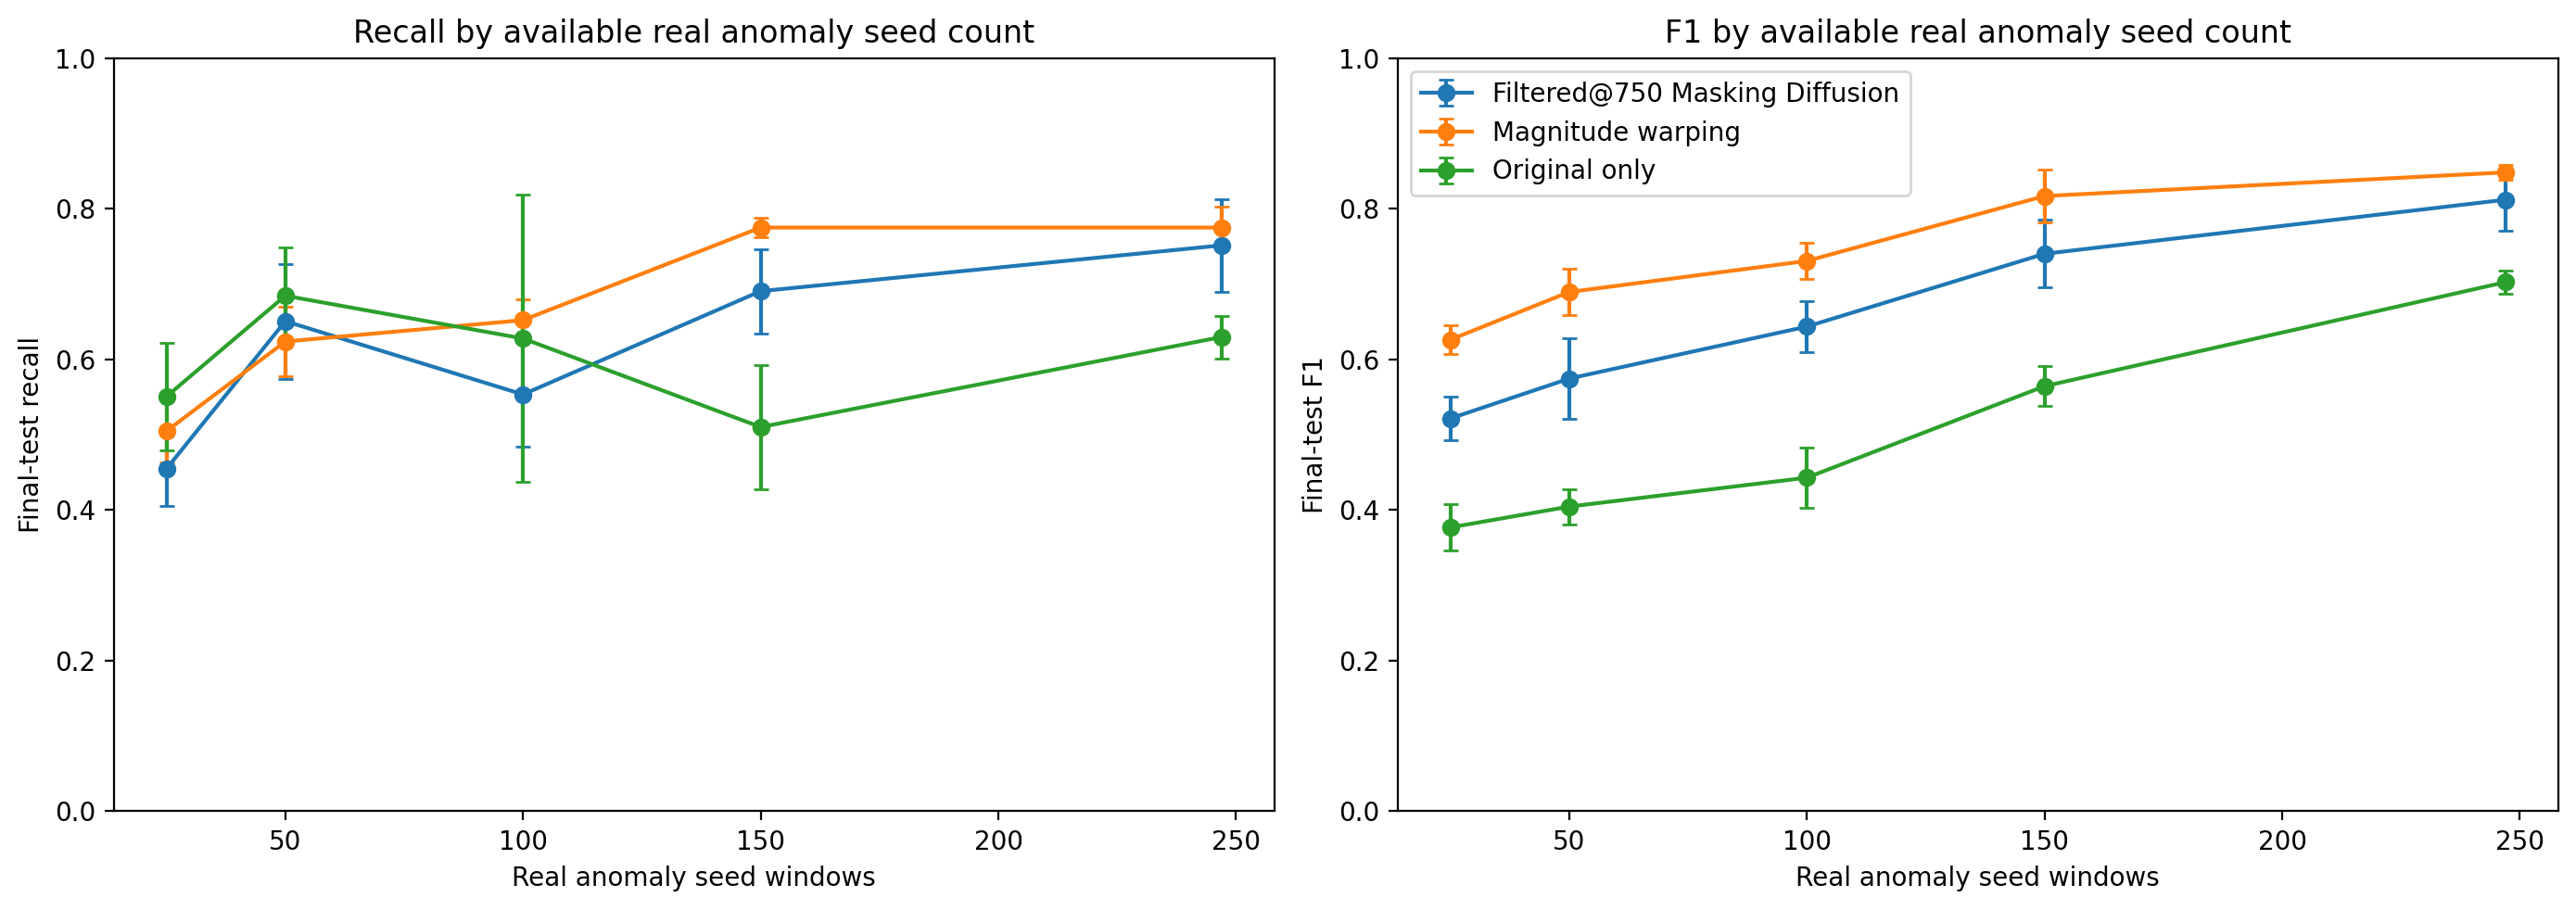

In [16]:
ANOMALY_SEED_COUNTS = [25, 50, 100, 150, 247]
SCARCE_SEEDS = [200, 201, 202, 203, 204]
scarce_rows = []

for n_seed in ANOMALY_SEED_COUNTS:
    for seed in SCARCE_SEEDS:
        x_seed_subset = sample_rows(x_anomaly_seed_all, n_seed, seed=seed + n_seed)
        generated_count = min(1000, max(0, 1247 - len(x_seed_subset)))

        filtered_md_subset = quality_filter_generated_anomalies(
            x_generated=x_masking_diffusion_pool,
            x_anomaly_seed=x_seed_subset,
            x_normal_train=sample_rows(x_normal_train, NORMAL_TRAIN_SIZE, seed=seed + 31),
            n_select=min(750, generated_count),
        )
        magnitude_generated = magnitude_warp(x_seed_subset, n_generate=generated_count, seed=seed + 102)

        scarce_rows.append(evaluate_augmented_rf(
            method='Original only',
            augmentation_family='none',
            x_anomaly_seed=x_seed_subset,
            x_generated=None,
            generated_count=0,
            seed=seed,
        ) | {'anomaly_seed_count': n_seed})
        scarce_rows.append(evaluate_augmented_rf(
            method='Magnitude warping',
            augmentation_family='traditional',
            x_anomaly_seed=x_seed_subset,
            x_generated=magnitude_generated,
            generated_count=generated_count,
            seed=seed,
        ) | {'anomaly_seed_count': n_seed})
        scarce_rows.append(evaluate_augmented_rf(
            method='Filtered@750 Masking Diffusion',
            augmentation_family='generative_filtered',
            x_anomaly_seed=x_seed_subset,
            x_generated=filtered_md_subset,
            generated_count=min(750, generated_count),
            seed=seed,
        ) | {'anomaly_seed_count': n_seed})

scarce_df = pd.DataFrame(scarce_rows)
scarce_df.to_csv(RESULT_DIR / 'research07_scarce_seed_runs.csv', index=False)

scarce_summary = (
    scarce_df
    .groupby(['anomaly_seed_count', 'method'])[['precision', 'recall', 'f1', 'f2', 'auprc', 'false_negative']]
    .agg(['mean', 'std', 'min', 'max'])
)
scarce_summary.columns = ['_'.join(col).strip() for col in scarce_summary.columns]
scarce_summary = scarce_summary.reset_index()
scarce_summary.to_csv(RESULT_DIR / 'research07_scarce_seed_summary.csv', index=False)
display(scarce_summary.sort_values(['anomaly_seed_count', 'recall_mean'], ascending=[True, False]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
for method, group in scarce_summary.groupby('method'):
    group = group.sort_values('anomaly_seed_count')
    axes[0].errorbar(
        group['anomaly_seed_count'],
        group['recall_mean'],
        yerr=group['recall_std'],
        marker='o',
        capsize=3,
        label=method,
    )
    axes[1].errorbar(
        group['anomaly_seed_count'],
        group['f1_mean'],
        yerr=group['f1_std'],
        marker='o',
        capsize=3,
        label=method,
    )

axes[0].set_title('Recall by available real anomaly seed count')
axes[0].set_ylabel('Final-test recall')
axes[0].set_xlabel('Real anomaly seed windows')
axes[0].set_ylim(0, 1.0)

axes[1].set_title('F1 by available real anomaly seed count')
axes[1].set_ylabel('Final-test F1')
axes[1].set_xlabel('Real anomaly seed windows')
axes[1].set_ylim(0, 1.0)
axes[1].legend(loc='best')

scarce_seed_figure_path = FIGURE_DIR / 'research07_scarce_seed_efficiency_comparison.png'
fig.tight_layout()
fig.savefig(scarce_seed_figure_path, dpi=200, bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(scarce_seed_figure_path)))

해석 기준:

- 낮은 anomaly seed count에서 `Filtered@750 Masking Diffusion`의 recall/F1 하락 폭이 작으면, 생성모델은 anomaly sample이 부족한 조건에서 유리하다고 주장할 수 있다.
- `Original only` 대비 개선 폭이 크고, `Magnitude warping`과 비슷하거나 더 높은 recall을 유지하면 가장 좋은 근거가 된다.
- 247개 전체 seed 조건에서 차이가 작더라도 25~100개 구간에서 차이가 커지면, 생성모델의 강점은 데이터 부족 상황으로 제한해서 설명하는 것이 좋다.

그래프 해석:

- 왼쪽 그래프는 사용 가능한 real anomaly seed 수가 줄어들 때 recall이 얼마나 유지되는지 보여준다.
- 오른쪽 그래프는 같은 조건에서 F1이 얼마나 유지되는지 보여준다. 적은 seed 구간에서 filtered 생성 증강의 하락 폭이 작으면 scarce-anomaly setting에서의 강점으로 제시할 수 있다.

## 최종 결론 작성 템플릿

Research07 결과를 확인한 뒤, 아래 문장 중 실제 결과로 지지되는 내용만 선택해서 사용한다. 생성모델이 전통 증강보다 항상 더 정확하다고 쓰기보다는, 어떤 조건에서 어떤 강점이 확인되었는지를 좁고 명확하게 정리한다.

### 안정성 결과가 좋을 때

> Filtered Masking Diffusion은 평균 F1 또는 AUPRC 기준에서 전통 증강을 명확히 앞서지는 않았지만, 반복 실험에서 recall의 변동 폭이 더 작게 나타났다. 이는 quality filtering을 적용한 생성 증강이 결함 탐지에서 더 안정적인 recall 중심 학습 신호를 제공할 수 있음을 보여준다.

### Threshold 견고성 결과가 좋을 때

> Validation precision 기준을 일정 수준 이상으로 유지했을 때, Filtered Masking Diffusion은 전통 증강 baseline보다 더 넓은 threshold 구간에서 높은 final-test recall을 유지했다. 이는 anomaly를 놓치지 않는 것이 중요한 상황에서 filtered 생성 증강이 특정 threshold 하나에 덜 의존하는 recall-oriented 장점을 가질 수 있음을 의미한다.

### 소수 anomaly seed 결과가 좋을 때

> real anomaly seed window 수를 줄였을 때 filtered 생성 증강의 효과가 더 뚜렷하게 나타났다. 이는 생성 증강이 anomaly sample이 충분한 조건보다는, 실제 anomaly 데이터가 부족한 scarce-anomaly setting에서 더 유용할 수 있음을 시사한다.

### 결과가 혼재될 때

> 본 결과는 생성 증강이 전통 증강보다 보편적으로 더 높은 정확도를 제공한다는 주장을 지지하지는 않는다. 대신 quality-filtered Masking Diffusion은 F1 기준으로 전통 증강과 경쟁 가능한 수준에 도달했고, 일부 조건에서는 recall 개선 가능성을 보였다. 따라서 생성 증강은 일반적인 accuracy-maximizing 방법이라기보다, recall 중심 결함 탐지 또는 anomaly sample이 부족한 조건에서 보완적으로 활용할 수 있는 증강 전략으로 해석하는 것이 적절하다.

## 저장 결과 파일

실행 후 다음 파일이 저장된다.

- `data/research07/results/research07_stability_runs.csv`
- `data/research07/results/research07_stability_summary.csv`
- `data/research07/results/research07_threshold_sweep.csv`
- `data/research07/results/research07_threshold_robustness_summary.csv`
- `data/research07/results/research07_scarce_seed_runs.csv`
- `data/research07/results/research07_scarce_seed_summary.csv`
- `data/research07/figures/research07_stability_recall_comparison.png`
- `data/research07/figures/research07_threshold_robustness_comparison.png`
- `data/research07/figures/research07_scarce_seed_efficiency_comparison.png`